# **Mestrado em Ciência de Dados - 2.º Ano**
**Aluno:** Miguel Loureiro | 2220134

**Instituição:** Universidade de Leiria e Oeste  

***Dissertação:*** Data Mining Aplicado à Transformação Digital de uma PME Portuguesa de E-commerce: Um Caso de Estudo Integrado

---

# **Notebook 4. Modelação | Grid Search - Otimização de Hiperparâmetros**
*O presente notebook engloba a otimização de hiperparâmetros do problema de classificação supervisionada aplicada à previsão de recompra de clientes iniciado no notebook anterior.*

---

### **Posicionamento do notebook na pipeline**

Este notebook retrata o processo de otimização de hiperparâmetros do problema de classificação em estudo, dando continuidade ao Notebook 3 (Baseline). Neste processo, é aplicado Grid Search a cada um dos quatro algoritmos com o objetivo de comparar os ganhos obtidos em relação à baseline, culminando na seleção do modelo final a recomendar à PME.

### **Boas práticas adotadas**

- **`GridSearchCV` sobre `Pipeline(StandardScaler + estimador)`** - o scaler é ajustado em cada fold apenas sobre os dados de treino do fold, eliminando *data leakage*.
- **`param_grid` com prefixo `clf__`** - parametrização do estimador dentro da Pipeline.
- **`GridSearchCV.fit` apenas sobre `X_train`** - manutenção do conjunto de teste independente durante toda a fase de otimização.
- **`StratifiedKFold` (10 folds)** - utilização da mesma configuração da baseline, assegurando comparabilidade direta.
- **`refit=True` (default)** - o melhor estimador é automaticamente treinado novamente sobre todo o `X_train` com os melhores hiperparâmetros.

### **Hiperparâmetros otimizados**

| Algoritmo | Hiperparâmetros |
|-----------|------------------|
| Regressão Logística | `C`, `penalty`, `solver` |
| SVM | `C`, `kernel`, `gamma` |
| Decision Tree | `max_depth`, `min_samples_split`, `criterion` |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_split` |

---

## **Estrutura do notebook**

1. Importação de bibliotecas.
2. Carregamento e validação de dados.
3. Definição do dataset.
4. Divisão em conjunto de treino e teste (80/20 estratificado).
5. Definição da validação cruzada (StratifiedKFold 10-fold).
6. Otimização de hiperparâmetros (Grid Search) nos quatro algoritmos: Regressão Logística, SVM, Decision Tree, Random Forest.
7. Resumo dos melhores hiperparâmetros.
8. Seleção de Features.
9. Retreino e persistência dos modelos otimizados.
10. Avaliação no conjunto de teste através de matrizes de confusão e tabela comparativa Baseline vs Grid Search.
11. Seleção do modelo final com fundamentação dos critérios e implicação prática para o negócio.

## **1. Importação de Bibliotecas**

O início do notebook está associado à importação das bibliotecas necessárias para a otimização de hiperparâmetros, incluindo as componentes de Grid Search e avaliação das métricas essenciais.

In [ ]:
#Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Utilitários de modelação e avaliação,
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)

# Pipeline e pré-processamento
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Algoritmos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de avaliação
from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay
)

## **2. Carregamento e Validação de Dados**

De seguida, procede-se ao carregamento do dataset resultante da fase de Preparação de Dados (`dataset_modelo_compra.csv`), seguindo-se uma validação dos dados ao nível de estrutura, valores nulos e infinitos.

In [ ]:
# Montar a Google Drive para acesso aos ficheiros essenciais
from google.colab import drive
drive.mount('/content/drive')

# Carregamento do dataset preparado
df_modelo = pd.read_csv("/content/drive/MyDrive/dataset_modelo_compra.csv")

print(f"Dimensão do dataset: {df_modelo.shape}")
print(f"\nColunas: {list(df_modelo.columns)}")
print(f"\nValores nulos:\n{df_modelo.isnull().sum()[df_modelo.isnull().sum()>0]}")
print(f"\nValores infinitos: {np.isinf(df_modelo.select_dtypes(include='number')).sum().sum()}")
print(f"\nDistribuição Target_Compra:")
print(df_modelo['Target_Compra'].value_counts(normalize=True).round(4))

Mounted at /content/drive
Dimensão do dataset: (2257, 13)

Colunas: ['Recency_FW', 'Monetary_FW', 'Ticket_Medio_FW', 'Produtos_Medios_FW', 'Freq_Mensal_FW', 'Dias_Entre_Compras_FW', 'Tempo_Cliente_FW', 'Perc_Desconto_FW', 'Num_Produtos_FW', 'Num_Categorias_FW', 'Num_Marcas_FW', 'Num_Tipos_FW', 'Target_Compra']

Valores nulos:
Series([], dtype: int64)

Valores infinitos: 0

Distribuição Target_Compra:
Target_Compra
0    0.634
1    0.366
Name: proportion, dtype: float64


## **3. Definição do Dataset**

O conjunto de dados a utilizar é composto pelas 12 features identificadas após remoção de `Frequency_FW` e pela variável alvo `Target_Compra`.

In [ ]:
# Conjunto de features (12 variáveis)
features = [
    'Recency_FW',
    'Monetary_FW',
    'Ticket_Medio_FW',
    'Produtos_Medios_FW',
    'Freq_Mensal_FW',
    'Dias_Entre_Compras_FW',
    'Tempo_Cliente_FW',
    'Perc_Desconto_FW',
    'Num_Produtos_FW',
    'Num_Categorias_FW',
    'Num_Marcas_FW',
    'Num_Tipos_FW'
]

X = df_modelo[features]
y = df_modelo['Target_Compra']

print(f"Dimensão de X: {X.shape}")
print(f"\nDistribuição Target_Compra:")
print(y.value_counts(normalize=True).round(4))

Dimensão de X: (2257, 12)

Distribuição Target_Compra:
Target_Compra
0    0.634
1    0.366
Name: proportion, dtype: float64


O dataset a utilizar é composto por 2.257 registos e por 12 features, sendo obtida uma distribuição da variável-alvo de 63,40% clientes que não recompram e 36,60% que voltam a comprar.

## **4. Divisão em Conjunto de Treino e Teste**

A divisão treino/teste (80%/20%) é realizada com `stratify=y` e `random_state=42`, assegurando a mesma proporção de classes em ambos os conjuntos e a comparabilidade direta com os resultados da baseline.

In [ ]:
# Split treino/teste (80/20) estratificado
# stratify=y assegura ~37%/63% em ambos os conjuntos, evitando enviesamento na avaliação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} registos | Teste: {X_test.shape[0]} registos")
print(f"\nDistribuição no treino:")
print(y_train.value_counts(normalize=True).round(4))
print(f"\nDistribuição no teste:")
print(y_test.value_counts(normalize=True).round(4))

Treino: 1805 registos | Teste: 452 registos

Distribuição no treino:
Target_Compra
0    0.6338
1    0.3662
Name: proportion, dtype: float64

Distribuição no teste:
Target_Compra
0    0.635
1    0.365
Name: proportion, dtype: float64


A divisão realizada demonstra que o conjunto de treino possui 1.805 registos e o conjunto de treino os restantes 452 registos, mantendo assim uma distribuição muito semelhante em termos percentuais (classe 0 = 63,50% e classe 1 = 36,50%).

## **5. Definição da Validação Cruzada**

A validação cruzada segue a mesma configuração da baseline: `StratifiedKFold` com 10 folds, `shuffle=True` e `random_state=42`, assegurando a coerência do processo e a comparabilidade direta.

In [ ]:
# Validação cruzada estratificada 10-fold - bom trade-off entre variância da estimativa e custo computacional
# shuffle=True: elimina enviesamento por ordenação temporal/alfabética dos registos
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

OS hiperparâmetros selecionados são específicos para cada algoritmo, sendo os parâmetros representados pelo prefixo `clf__` para corresponderem ao nome do estimador dentro da `Pipeline`.

## **6. Otimização de Hiperparâmetros (Grid Search)**

São otimizados os quatro algoritmos via `GridSearchCV`, com escolha de `scoring='recall'` e validação cruzada estratificada 10-fold. Cada algoritmo é integrado em `Pipeline(StandardScaler + estimador)`, sendo que as chaves do `param_grid` usam o prefixo `clf__` para parametrizar o estimador dentro da Pipeline.

Hiperparâmetros otimizados por modelo:
- **Regressão Logística** - `C`, `penalty`, `solver`
- **SVM** - `C`, `kernel`, `gamma`
- **Decision Tree** - `max_depth`, `min_samples_split`, `criterion`
- **Random Forest** - `n_estimators`, `max_depth`, `min_samples_split`

### **6.1. Regressão Logística**

In [ ]:
# Pipeline = StandardScaler + LogisticRegression
# Chaves com prefixo 'clf__' porque os parâmetros pertencem ao passo 'clf' da Pipeline
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# C: força de regularização (menor = mais regularização)
# penalty l1: seleção implícita de features / l2: encolhe coeficientes
# solver: 'liblinear' suporta l1 em datasets pequenos; 'saga' suporta ambos e é mais escalável
param_grid_lr = {
    'clf__C':            [0.01, 0.1, 1, 10],
    'clf__penalty':      ['l1', 'l2'],
    'clf__solver':       ['liblinear', 'saga'],
    'clf__class_weight': ['balanced']
}

# scoring='recall': otimização direcionada à métrica primária (minimizar FN)
# n_jobs=-1: paraleliza sobre todos os cores disponíveis
grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring='recall', cv=cv, n_jobs=-1, verbose=1
)
grid_lr.fit(X_train, y_train)

print(f"Melhores parâmetros - RL: {grid_lr.best_params_}")
print(f"Melhor Recall CV: {grid_lr.best_score_:.4f}")

Fitting 10 folds for each of 16 candidates, totalling 160 fits
Melhores parâmetros - RL: {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Melhor Recall CV: 0.7367


A otimização da Regressão Logística é feita mediante os parâmetros `C`, `penalty` (`l1`/`l2`) e `solver`. A combinação `(penalty='l1', solver='liblinear')` permite obter sparsity nos coeficientes, enquanto a combinação `(penalty='l2', solver='saga')` é mais adequada a datasets maiores. A `Pipeline` garante que o `StandardScaler` é ajustado apenas sobre o treino em cada fold. O melhor Recall registado após otimização foi 0,7367.

### **6.2. SVM**

In [ ]:
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(random_state=42))
])

# kernel: 'linear' assume fronteira linear; 'rbf' captura relações não-lineares (fronteira flexível)
# gamma: influência de cada ponto no kernel RBF
# probability=True: necessário para métricas baseadas em probabilidades (ROC-AUC)
param_grid_svm = {
    'clf__C':            [0.1, 1, 10],
    'clf__kernel':       ['linear', 'rbf'],
    'clf__gamma':        ['scale', 'auto'],
    'clf__class_weight': ['balanced'],
    'clf__probability':  [True]
}

grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring='recall', cv=cv, n_jobs=-1, verbose=1
)
grid_svm.fit(X_train, y_train)

print(f"Melhores parâmetros - SVM: {grid_svm.best_params_}")
print(f"Melhor Recall CV: {grid_svm.best_score_:.4f}")

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Melhores parâmetros - SVM: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__probability': True}
Melhor Recall CV: 0.7685


A otimização do SVM realiza combinações de `C`, `kernel` e `gamma` para maximizar o Recall através do conjunto de hiperparâmetros padrão. A `Pipeline` garante que a normalização (essencial para o SVM, que é sensível a escala) é ajustada apenas sobre os dados de treino em cada fold. O melhor valor de Recall registado foi de 0,7685, sendo superior ao valor obtido na otimização na Regressão Logística.

### **6.3. Decision Tree**

In [ ]:
pipe_dt = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=42))
])

# max_depth: controla profundidade da árvore
# min_samples_split: mínimo de amostras para dividir um nó
# criterion: 'gini' (impureza) vs 'entropy' (ganho de informação)
param_grid_dt = {
    'clf__max_depth':         [3, 5, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__criterion':         ['gini', 'entropy'],
    'clf__class_weight':      ['balanced']
}

grid_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid_dt,
    scoring='recall', cv=cv, n_jobs=-1, verbose=1
)
grid_dt.fit(X_train, y_train)

print(f"Melhores parâmetros - DT: {grid_dt.best_params_}")
print(f"Melhor Recall CV: {grid_dt.best_score_:.4f}")

Fitting 10 folds for each of 24 candidates, totalling 240 fits
Melhores parâmetros - DT: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_split': 2}
Melhor Recall CV: 0.8123


A otimização da Decision Tree com os parâmetros `max_depth`, `min_samples_split` e `criterion` auxilia no controlo da complexidade da árvore e na mitigação de overfitting. A grelha inclui `max_depth=3,5,10,None` para que seja possível avaliar diferentes graus de regularização. O melhor valor de Recall registado foi de 0,8123, sendo o maior valor obtido na otimização dos três algoritmos até agora utilizados.

### **6.4. Random Forest**

In [ ]:
pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42))
])

# n_estimators: número de árvores; mais árvores = mais estabilidade mas maior custo computacional
# max_depth e min_samples_split: mesmos controlos que Decision Tree, aplicados a cada árvore do ensemble
param_grid_rf = {
    'clf__n_estimators':      [100, 200, 300],
    'clf__max_depth':         [5, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__class_weight':      ['balanced']
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='recall', cv=cv, n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)

print(f"Melhores parâmetros - RF: {grid_rf.best_params_}")
print(f"Melhor Recall CV: {grid_rf.best_score_:.4f}")

Fitting 10 folds for each of 27 candidates, totalling 270 fits
Melhores parâmetros - RF: {'clf__class_weight': 'balanced', 'clf__max_depth': 5, 'clf__min_samples_split': 10, 'clf__n_estimators': 300}
Melhor Recall CV: 0.7519


A otimização do Random Forest de `n_estimators`, `max_depth` e `min_samples_split` é essencial para ajustar a capacidade do conjunto de árvores, sendo tipicamente menos sensível a hiperparâmetros do que modelos individuais. O melhor valor de Recall registado foi de 0,7519, sendo inferior ao melhor valor registado na Decision Tree (0,8123).

## **7. Resumo dos Melhores Hiperparâmetros**

Após a execução do Grid Search aos quatro algoritmos, apresenta-se uma tabela consolidada com a identificação dos melhores hiperparâmetros e o Recall médio obtido em cada combinação.

In [ ]:
resumo_grid = []
modelos_grid = [
    ('Regressão Logística', grid_lr),
    ('SVM',                 grid_svm),
    ('Decision Tree',       grid_dt),
    ('Random Forest',       grid_rf),
]

for nome, g in modelos_grid:
    resumo_grid.append({
        'Modelo': nome,
        'Recall CV': round(g.best_score_, 4),
        'Melhores Parâmetros': str(g.best_params_),
    })

df_resumo_grid = pd.DataFrame(resumo_grid).sort_values('Recall CV', ascending=False)

print("Resumo Grid Search\n")
print(df_resumo_grid[['Modelo','Recall CV']].to_string(index=False))
print("\n\nMelhores parâmetros por modelo:\n")
for nome, g in modelos_grid:
    print(f"  {nome}: {g.best_params_}")

Resumo Grid Search

             Modelo  Recall CV
      Decision Tree     0.8123
                SVM     0.7685
      Random Forest     0.7519
Regressão Logística     0.7367


Melhores parâmetros por modelo:

  Regressão Logística: {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
  SVM: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__probability': True}
  Decision Tree: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_split': 2}
  Random Forest: {'clf__class_weight': 'balanced', 'clf__max_depth': 5, 'clf__min_samples_split': 10, 'clf__n_estimators': 300}


A tabela apresentada identifica o modelo com maior Recall (0,8123) na validação cruzada, **Decision Tree**, sendo um forte candidato a modelo final mediante confirmação nas próximas secções que incluem o processo de seleção de features ee o retreino dos modelos.

## **8. Seleção de Features**

Nesta secção é realizada a seleção de features para cada um dos quatro algoritmos, sendo um processo que visa identificar o número ótimo de variáveis que permite maximizar o Recall.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

### **8.1. Regressão Logística**

k=1: Recall médio = 0.7201
k=2: Recall médio = 0.6535
k=3: Recall médio = 0.6550
k=4: Recall médio = 0.6535
k=5: Recall médio = 0.6989
k=6: Recall médio = 0.7156
k=7: Recall médio = 0.7185
k=8: Recall médio = 0.7201
k=9: Recall médio = 0.7291
k=10: Recall médio = 0.7337
k=11: Recall médio = 0.7291
k=12: Recall médio = 0.7367


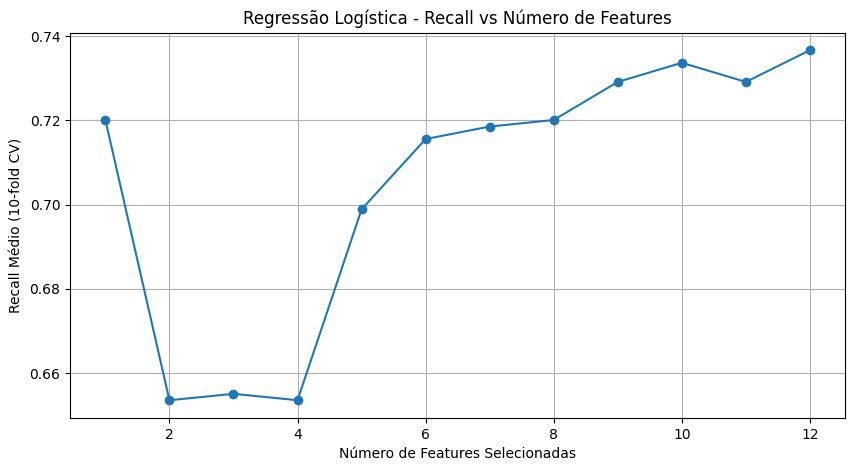


Melhor número de features para Regressão Logística: 12


In [ ]:
# Avaliação para diferentes valores de k (features selecionadas) - Regressão Logística
# Feature selection após otimização de hiperparâmetros: mantém os melhores parâmetros fixos
best_params_lr = grid_lr.best_params_
k_values = list(range(1, X_train.shape[1] + 1))
recall_scores_k_lr = []

# Loop manual sobre k (não GridSearchCV), pois o objetivo é traçar a curva Recall vs k
# para permitir escolha visual do ponto de estabilização
for k in k_values:
# Pipeline agora com 3 passos: scaler → SelectKBest → clf
# SelectKBest dentro da Pipeline: seleção de features é refeita em cada fold, evitando data leakage
    pipeline_fs = Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(score_func=f_classif, k=k)),
        ('clf', LogisticRegression(
            C=best_params_lr['clf__C'],
            penalty=best_params_lr['clf__penalty'],
            solver=best_params_lr['clf__solver'],
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ])

    scores = []
    for train_idx, test_idx in cv.split(X_train, y_train):
        X_cv_train, X_cv_test = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_cv_train, y_cv_test = y_train.iloc[train_idx], y_train.iloc[test_idx]
        pipeline_fs.fit(X_cv_train, y_cv_train)
        y_pred = pipeline_fs.predict(X_cv_test)
        scores.append(recall_score(y_cv_test, y_pred))

    recall_scores_k_lr.append(np.mean(scores))

#Visualizar os resultados
for k, score in zip(k_values, recall_scores_k_lr):
    print(f"k={k}: Recall médio = {score:.4f}")

#Gráfico
plt.figure(figsize=(10,5))
plt.plot(k_values, recall_scores_k_lr, marker='o')
plt.title('Regressão Logística - Recall vs Número de Features')
plt.xlabel('Número de Features Selecionadas')
plt.ylabel('Recall Médio (10-fold CV)')
plt.grid(True)
plt.show()

# Escolha do k que maximiza o Recall médio em CV
best_k_lr = k_values[np.argmax(recall_scores_k_lr)]
print(f"\nMelhor número de features para Regressão Logística: {best_k_lr}")

A curva apresenta uma tendência crescente a partir da seleção de quatro features, sendo que o Recall aumenta progressivamente com o número de features incluídas. O valor máximo de Recall registado acontece em k=12 (Recall = 0,7367), ou seja, incluindo todas as features.

### **8.2. SVM**

k=1: Recall médio = 0.7201
k=2: Recall médio = 0.7383
k=3: Recall médio = 0.7231
k=4: Recall médio = 0.6899
k=5: Recall médio = 0.7881
k=6: Recall médio = 0.7579
k=7: Recall médio = 0.7609
k=8: Recall médio = 0.7654
k=9: Recall médio = 0.7685
k=10: Recall médio = 0.7715
k=11: Recall médio = 0.7700
k=12: Recall médio = 0.7685


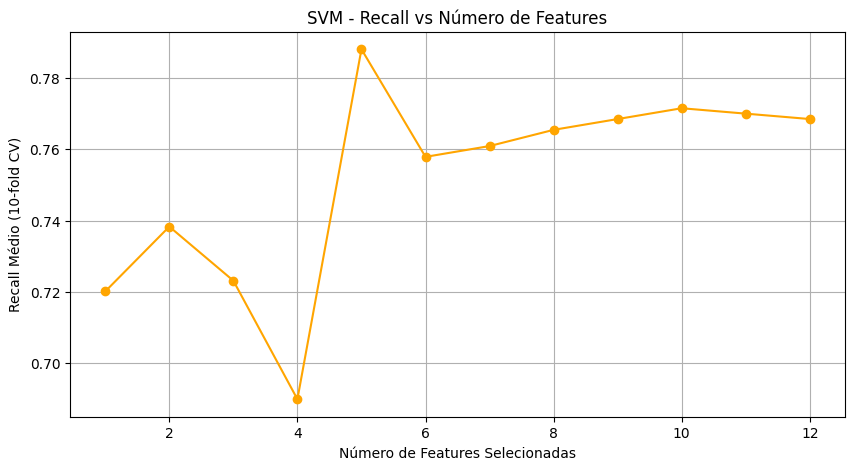


Melhor número de features para SVM: 5


In [ ]:
#Avaliação para diferentes valores de k - SVM
best_params_svm = grid_svm.best_params_
recall_scores_k_svm = []

for k in k_values:
    pipeline_fs = Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(score_func=f_classif, k=k)),
        ('clf', SVC(
            C=best_params_svm['clf__C'],
            kernel=best_params_svm['clf__kernel'],
            gamma=best_params_svm['clf__gamma'],
            class_weight='balanced',
            probability=True,
            random_state=42
        ))
    ])

    scores = []
    for train_idx, test_idx in cv.split(X_train, y_train):
        X_cv_train, X_cv_test = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_cv_train, y_cv_test = y_train.iloc[train_idx], y_train.iloc[test_idx]

        pipeline_fs.fit(X_cv_train, y_cv_train)
        y_pred = pipeline_fs.predict(X_cv_test)
        scores.append(recall_score(y_cv_test, y_pred))

    recall_scores_k_svm.append(np.mean(scores))

for k, score in zip(k_values, recall_scores_k_svm):
    print(f"k={k}: Recall médio = {score:.4f}")

plt.figure(figsize=(10,5))
plt.plot(k_values, recall_scores_k_svm, marker='o', color='orange')
plt.title('SVM - Recall vs Número de Features')
plt.xlabel('Número de Features Selecionadas')
plt.ylabel('Recall Médio (10-fold CV)')
plt.grid(True)
plt.show()

best_k_svm = k_values[np.argmax(recall_scores_k_svm)]
print(f"\nMelhor número de features para SVM: {best_k_svm}")

A curva atinge o valor máximo em k=5, com Recall = 0,7881, seguindo-se uma redução logo de seguida e um aumento gradual com as restantes variáveis sem atingir novamente o valor máximo.

### **8.3. Decision Tree**

k=1: Recall médio = 0.7201
k=2: Recall médio = 0.7201
k=3: Recall médio = 0.7201
k=4: Recall médio = 0.7201
k=5: Recall médio = 0.7185
k=6: Recall médio = 0.7140
k=7: Recall médio = 0.8153
k=8: Recall médio = 0.7836
k=9: Recall médio = 0.7942
k=10: Recall médio = 0.7942
k=11: Recall médio = 0.8123
k=12: Recall médio = 0.8123


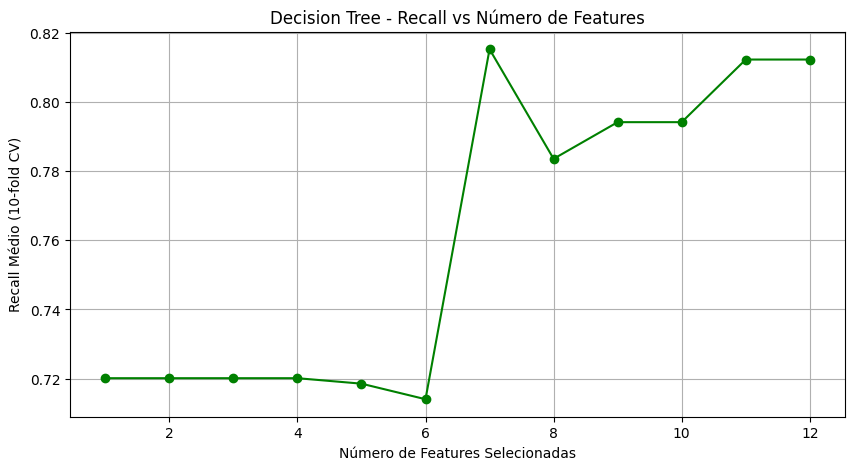


Melhor número de features para Decision Tree: 7


In [ ]:
#Avaliação para diferentes valores de k - Decision Tree
best_params_dt = grid_dt.best_params_
recall_scores_k_dt = []

for k in k_values:
    pipeline_fs = Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(score_func=f_classif, k=k)),
        ('clf', DecisionTreeClassifier(
            max_depth=best_params_dt['clf__max_depth'],
            min_samples_split=best_params_dt['clf__min_samples_split'],
            criterion=best_params_dt['clf__criterion'],
            class_weight='balanced',
            random_state=42
        ))
    ])

    scores = []
    for train_idx, test_idx in cv.split(X_train, y_train):
        X_cv_train, X_cv_test = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_cv_train, y_cv_test = y_train.iloc[train_idx], y_train.iloc[test_idx]

        pipeline_fs.fit(X_cv_train, y_cv_train)
        y_pred = pipeline_fs.predict(X_cv_test)
        scores.append(recall_score(y_cv_test, y_pred))

    recall_scores_k_dt.append(np.mean(scores))

for k, score in zip(k_values, recall_scores_k_dt):
    print(f"k={k}: Recall médio = {score:.4f}")

plt.figure(figsize=(10,5))
plt.plot(k_values, recall_scores_k_dt, marker='o', color='green')
plt.title('Decision Tree - Recall vs Número de Features')
plt.xlabel('Número de Features Selecionadas')
plt.ylabel('Recall Médio (10-fold CV)')
plt.grid(True)
plt.show()

best_k_dt = k_values[np.argmax(recall_scores_k_dt)]
print(f"\nMelhor número de features para Decision Tree: {best_k_dt}")

A curva evidencia um valor relativamente constante entre k=1 e k=6 e depois um aumento substancial de k=6 para k=7, onde se obtém um valor máximo de 0,8153.

### **8.4. Random Forest**

k=1: Recall médio = 0.7201
k=2: Recall médio = 0.7292
k=3: Recall médio = 0.7277
k=4: Recall médio = 0.7110
k=5: Recall médio = 0.7578
k=6: Recall médio = 0.7533
k=7: Recall médio = 0.7458
k=8: Recall médio = 0.7458
k=9: Recall médio = 0.7549
k=10: Recall médio = 0.7610
k=11: Recall médio = 0.7518
k=12: Recall médio = 0.7519


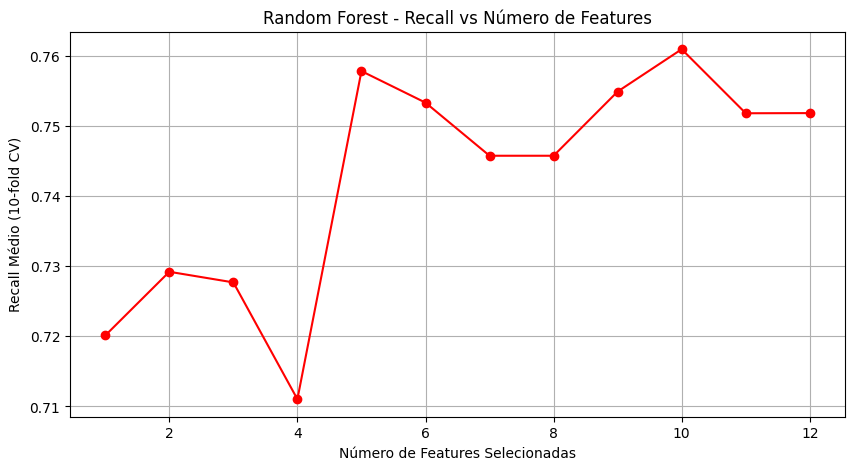


Melhor número de features para Random Forest: 10


In [ ]:
#Avaliação para diferentes valores de k - Random Forest
best_params_rf = grid_rf.best_params_
recall_scores_k_rf = []

for k in k_values:
    pipeline_fs = Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(score_func=f_classif, k=k)),
        ('clf', RandomForestClassifier(
            n_estimators=best_params_rf['clf__n_estimators'],
            max_depth=best_params_rf['clf__max_depth'],
            min_samples_split=best_params_rf['clf__min_samples_split'],
            class_weight='balanced',
            random_state=42
        ))
    ])

    scores = []
    for train_idx, test_idx in cv.split(X_train, y_train):
        X_cv_train, X_cv_test = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_cv_train, y_cv_test = y_train.iloc[train_idx], y_train.iloc[test_idx]

        pipeline_fs.fit(X_cv_train, y_cv_train)
        y_pred = pipeline_fs.predict(X_cv_test)
        scores.append(recall_score(y_cv_test, y_pred))

    recall_scores_k_rf.append(np.mean(scores))

for k, score in zip(k_values, recall_scores_k_rf):
    print(f"k={k}: Recall médio = {score:.4f}")

plt.figure(figsize=(10,5))
plt.plot(k_values, recall_scores_k_rf, marker='o', color='red')
plt.title('Random Forest - Recall vs Número de Features')
plt.xlabel('Número de Features Selecionadas')
plt.ylabel('Recall Médio (10-fold CV)')
plt.grid(True)
plt.show()

best_k_rf = k_values[np.argmax(recall_scores_k_rf)]
print(f"\nMelhor número de features para Random Forest: {best_k_rf}")

A curva apresenta o valor máximo em k=10 (Recall = 0,7610), mas apresenta um comportamento irregular com altos e baixos, existindo um salto bastante significativo entre k=4 e k=5.

## **9. Retreino e Persistência dos Modelos Otimizados**

Os melhores estimadores resultantes do Grid Search são retreinados automaticamente sobre o conjunto de treino completo (`refit=True` é o default do `GridSearchCV`). Os modelos otimizados são guardados em disco para utilização futura sem necessidade de repetir o processo de otimização.

In [ ]:
# Retreino final: hiperparâmetros ótimos do GridSearchCV + k features selecionadas por modelo
# Estes .pkl são os modelos "otimizados" e substituem os baselines na análise final
os.makedirs("/content/drive/MyDrive/modelos", exist_ok=True)

modelos_otimizados = {
    "Regressao Logistica": Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(score_func=f_classif, k=best_k_lr)),
        ('clf', LogisticRegression(
            C=best_params_lr['clf__C'],
            penalty=best_params_lr['clf__penalty'],
            solver=best_params_lr['clf__solver'],
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(score_func=f_classif, k=best_k_svm)),
        ('clf', SVC(
            C=best_params_svm['clf__C'],
            kernel=best_params_svm['clf__kernel'],
            gamma=best_params_svm['clf__gamma'],
            class_weight='balanced',
            probability=True,
            random_state=42
        ))
    ]),
    "Decision Tree": Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(score_func=f_classif, k=best_k_dt)),
        ('clf', DecisionTreeClassifier(
            max_depth=best_params_dt['clf__max_depth'],
            min_samples_split=best_params_dt['clf__min_samples_split'],
            criterion=best_params_dt['clf__criterion'],
            class_weight='balanced',
            random_state=42
        ))
    ]),
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(score_func=f_classif, k=best_k_rf)),
        ('clf', RandomForestClassifier(
            n_estimators=best_params_rf['clf__n_estimators'],
            max_depth=best_params_rf['clf__max_depth'],
            min_samples_split=best_params_rf['clf__min_samples_split'],
            class_weight='balanced',
            random_state=42
        ))
    ])
}

# Fit sobre todo o X_train (sem CV) porque a validação já foi feita nas fases anteriores
for nome, modelo in modelos_otimizados.items():
    modelo.fit(X_train, y_train)
    nome_f = nome.replace(" ", "_").lower()
    joblib.dump(modelo, f"/content/drive/MyDrive/modelos/{nome_f}_otimizado_pipeline.pkl")
    print(f"Guardado: {nome_f}_otimizado_pipeline.pkl")

Guardado: regressao_logistica_otimizado_pipeline.pkl
Guardado: svm_otimizado_pipeline.pkl
Guardado: decision_tree_otimizado_pipeline.pkl
Guardado: random_forest_otimizado_pipeline.pkl


### **9.1. Features selecionadas**

Segue-se a apresentação do conjunto de features selecionado por algoritmo, permitindo identificar de forma clara quais as variáveis que contribuem para maximizar o Recall.

In [ ]:
# Lista que irá armazenar as features selecionadas por cada modelo
features_selecionadas = []

print("FEATURES SELECIONADAS POR MODELO")

# Percorre todos os modelos otimizados
for nome, modelo in modelos_otimizados.items():
    selector = modelo.named_steps['select']
    features = X_train.columns[selector.get_support()].tolist()

    features_selecionadas.append({
        "Modelo": nome,
        "k_features": len(features),
        "Features": " | ".join(features)
    })

# Apresenta no output o nome do modelo e o número de features selecionadas
    print(f"\n{nome}")
    print(f"Número de features selecionadas: {len(features)}")
    print("Features:")

# Apresenta individualmente cada feature selecionada e a respetiva posição
    for i, feature in enumerate(features, 1):
        print(f"  {i}. {feature}")

# Criar DataFrame
df_features_selecionadas = pd.DataFrame(features_selecionadas)

# Exportar para CSV
df_features_selecionadas.to_csv(
    "/content/drive/MyDrive/features_selecionadas_classificacao.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Features selecionadas exportadas para:")
print("/content/drive/MyDrive/features_selecionadas_classificacao.csv")

FEATURES SELECIONADAS POR MODELO

Regressao Logistica
Número de features selecionadas: 12
Features:
  1. Recency_FW
  2. Monetary_FW
  3. Ticket_Medio_FW
  4. Produtos_Medios_FW
  5. Freq_Mensal_FW
  6. Dias_Entre_Compras_FW
  7. Tempo_Cliente_FW
  8. Perc_Desconto_FW
  9. Num_Produtos_FW
  10. Num_Categorias_FW
  11. Num_Marcas_FW
  12. Num_Tipos_FW

SVM
Número de features selecionadas: 5
Features:
  1. Freq_Mensal_FW
  2. Tempo_Cliente_FW
  3. Num_Produtos_FW
  4. Num_Categorias_FW
  5. Num_Marcas_FW

Decision Tree
Número de features selecionadas: 7
Features:
  1. Recency_FW
  2. Freq_Mensal_FW
  3. Dias_Entre_Compras_FW
  4. Tempo_Cliente_FW
  5. Num_Produtos_FW
  6. Num_Categorias_FW
  7. Num_Marcas_FW

Random Forest
Número de features selecionadas: 10
Features:
  1. Recency_FW
  2. Monetary_FW
  3. Ticket_Medio_FW
  4. Freq_Mensal_FW
  5. Dias_Entre_Compras_FW
  6. Tempo_Cliente_FW
  7. Num_Produtos_FW
  8. Num_Categorias_FW
  9. Num_Marcas_FW
  10. Num_Tipos_FW
Features seleciona

A partir dos resultados obtidos, constata-se que:

- **Regressão Logística:** A seleção de todas as 12 variáveis coincide com a lógica de modelos lineares onde cada variável contribui de forma aditiva para a separação linear das classes. A regularização L2 (`penalty='l2'`) escolhida pelo Grid Search já controla o eventual sobre-ajuste (overfitting), tornando desnecessária a remoção de features. Desta forma, na Regressão Logística, a seleção de features via `SelectKBest` não traz benefício.

- **SVM:** O conjunto de features selecionado é interessante (`Freq_Mensal_FW`, `Tempo_Cliente_FW`, `Num_Produtos_FW`, `Num_Categorias_FW` e `Num_Marcas_FW`), na medida em que se tratam de variáveis de atividade e diversidade, não incluindo as variáveis RFM tradicionais (Recency_FW e Monetary_FW). Neste conjunto de features, a predição advém essencialmente do padrão de comportamento ao nível de frequência e diversidade e não da recência ou do valor monetário gasto.

- **Decision Tree:** Este resultado exclui cinco features de baixo poder discriminativo (`Monetary_FW`, `Ticket_Medio_FW`, `Produtos_Medios_FW`, `Perc_Desconto_FW`, `Num_Tipos_FW`).

- **Random Forest:** Apenas as variáveis `Produtos_Medios_FW` e `Perc_Desconto_FW` são excluídas, demonstrando a reduzida capacidade discriminativa das mesmas.

### **9.2. Visualização da Decision Tree otimizada**

O facto de a Decision Tree apresentar `max_depth=3` torna possível a sua visualização na integra, assim como a leitura direta das regras de decisão aprendidas pelo modelo, sendo um fator relevante para a equipa de marketing da PME ter capacidade de interpretar. Esta interpretabilidade é uma vantagem importante face aos restantes algoritmos (SVM, RF), permitindo à empresa compreender e avaliar o critério de classificação.

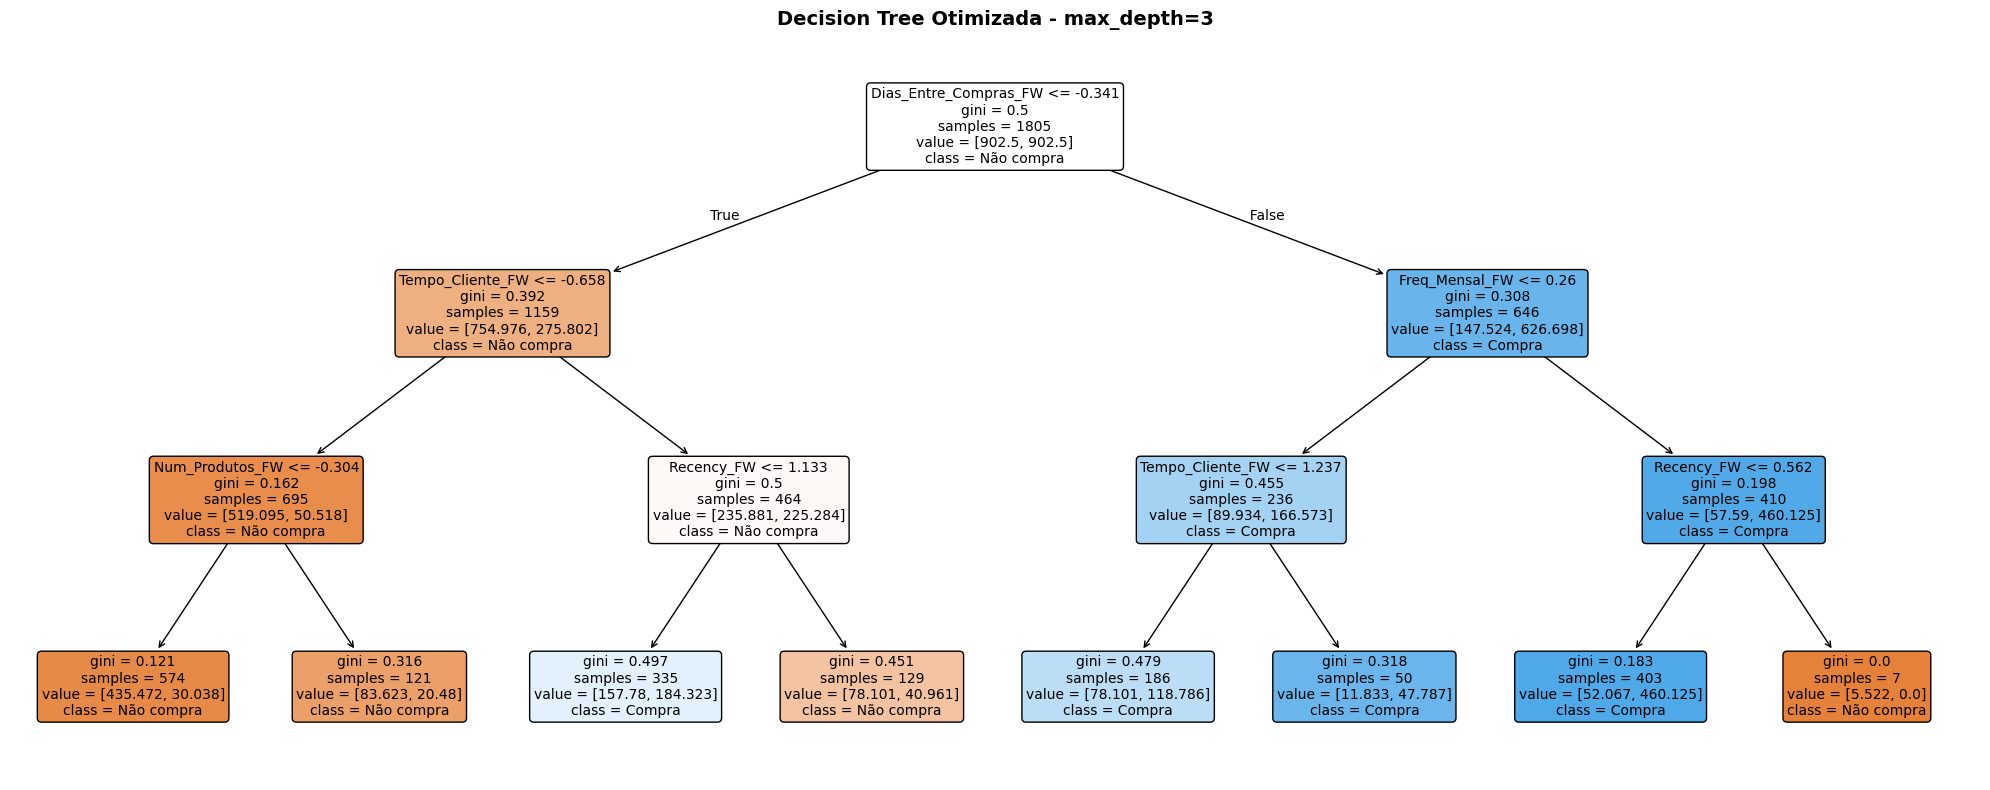

In [ ]:
from sklearn.tree import plot_tree

# Visualização apenas para a Decision Tree por ser o modelo interpretável escolhido como final
# max_depth=3 (do Grid Search) resulta em árvore legível para leitura académica
# Extrair a árvore otimizada e as features que selecionou
modelo_dt = modelos_otimizados['Decision Tree']
selector_dt = modelo_dt.named_steps['select']
features_dt = X_train.columns[selector_dt.get_support()].tolist()
clf_dt = modelo_dt.named_steps['clf']

#Visualizar árvore
plt.figure(figsize=(20, 8))
plot_tree(
    clf_dt,
    feature_names=features_dt,
    class_names=['Não compra', 'Compra'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Otimizada - max_depth=3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Conforme referido anteriormente, a árvore apresentada permite a leitura direta das regras, sendo que o nó raiz indica a feature mais discriminativa (`Dias_Entre_Compras_FW`) e cada nível seguinte contribui para refinar a classificação. O nível de interpretabilidade oferecido pela árvore permite à empresa ter uma vantagem ao nível de explicabilidade operacional, ou seja, qualquer cliente classificado como "vai comprar" pode ter o seu caminho na árvore mostrado ao gestor de marketing, justificando a decisão do modelo.

## **10. Avaliação dos Modelos Otimizados**

### **10.1. Matrizes de Confusão**

A avaliação dos modelos otimizados é realizada no conjunto de teste independente, isto é, em dados que não foram observados pelos modelos durante o treino ou a validação cruzada. Para tal, são apresentadas as matrizes de confusão para os quatro modelos, enfatizando a análise dos Falsos Negativos (clientes que comprariam, mas não foram identificados) e nos Falsos Positivos (clientes que não comprariam, mas foram classificados como compradores).

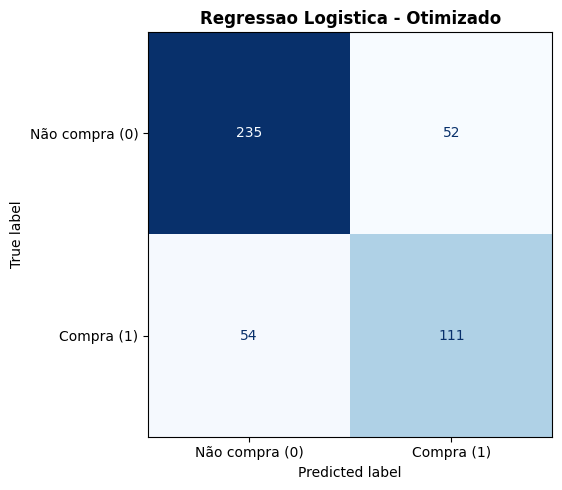

  Regressao Logistica: FN=54 (32.7%) | FP=52 (18.1%) | Recall=0.6727 | F1=0.6768



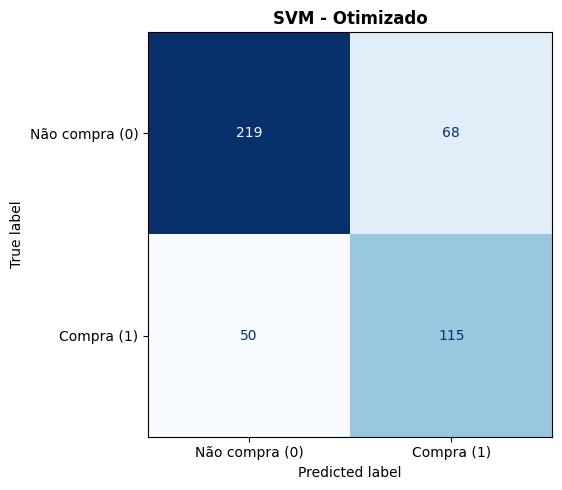

  SVM: FN=50 (30.3%) | FP=68 (23.7%) | Recall=0.6970 | F1=0.6609



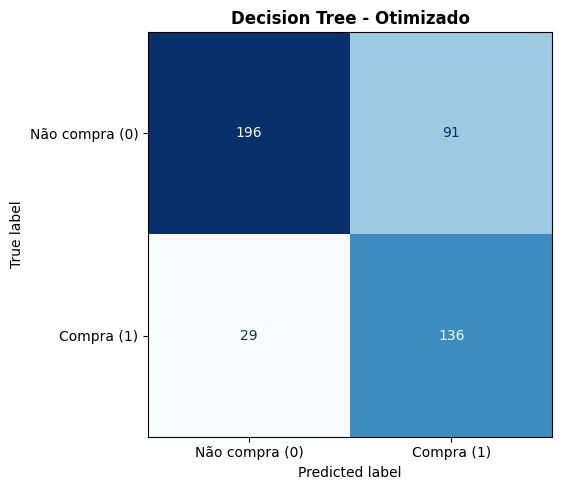

  Decision Tree: FN=29 (17.6%) | FP=91 (31.7%) | Recall=0.8242 | F1=0.6939



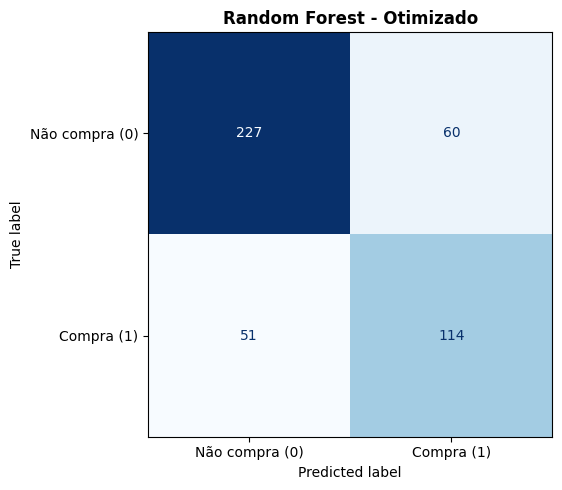

  Random Forest: FN=51 (30.9%) | FP=60 (20.9%) | Recall=0.6909 | F1=0.6726



In [ ]:
for nome, modelo in modelos_otimizados.items():
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Não compra (0)', 'Compra (1)']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nome} - Otimizado', fontweight='bold')
    plt.tight_layout()
    plt.show()

# ravel() da matriz 2x2: ordem (TN, FP, FN, TP) por convenção do sklearn
# Taxas: FN/(FN+TP) = 1-Recall (proporção de compradores não identificados)
#        FP/(FP+TN) = 1-Specificity (proporção de não-compradores classificados como compradores)
    vn, fp, fn, vp = cm.ravel()
    print(f"  {nome}: FN={fn} ({fn/(fn+vp):.1%}) | FP={fp} ({fp/(fp+vn):.1%}) "
          f"| Recall={recall_score(y_test, y_pred):.4f} | F1={f1_score(y_test, y_pred):.4f}\n")

As matrizes de confusão dos quatro modelos revelam o desempenho ao nível da identificação de clientes compradores e da redução de classificações incorretas, sendo de destacar os seguintes resultados:

- **Regressão Logística:** foram identificados corretamente 111 dos 165 clientes que realizaram uma nova compra, apresentando valores muito similares de falsos negativos (54) e falsos positivos (52). A proximidade de ambos os erros (FN e FP) demonstra que este modelo é estável e equilibrado, no entanto apresenta menor capacidade de deteção de compradores, apresentando o valor mais elevado de falsos negativos entre os quatro modelos (32,70%).

- **SVM:** identificou corretamente 115 clientes compradores e teve a capacidade de reduzir ligeiramente o número de falsos negativos para 50, demonstrando maior sensibilidade na deteção de clientes com maior potencial de recompra. Contudo, registou-se um aumento dos falsos positivos (68), levando a que a empresa realize mais campanhas dirigidas a clientes sem intenção de compra.

- **Decision Tree:** foi registada uma redução do número de falsos negativos para apenas 29 (17,6%), tendo a capacidade de identificar corretamente 136 dos 165 compradores, culminando no valor mais elevado registado ao analisar os restantes modelos. Este resultado está associado igualmente ao recall mais elevado (0,8242) e ao melhor F1-Score obtido (0,6939). No entanto, os ganhos obtidos levam ao maior volume de falsos positivos (91), levando a que sejam enviadas mais campanhas direcionadas a clientes que não voltariam a comprar.

- **Random Forest:** classificou 51 clientes como falsos negativos e 60 falsos positivos, tendo identificado corretamente 114 clientes compradores. Este modelo demonstra um comportamento equilibrado na deteção efetiva de recompra e na contenção de falsos alarmes.

Em conclusão, a Regressão Logística e o Random Forest estão associados a uma perspetiva mais conservadora, dado o menor volume de falsos alarmes, implicando também menor capacidade de captação. Por outro lado, a Decision Tree é claramente o modelo mais direcionado para a identificação de clientes com potencial de recompra, apesar do aumento dos falsos positivos. Dado que o objetivo desta problemática consiste em minimizar os Falsos Negativos e, assim, otimizar a deteção de clientes suscetíveis de voltar a comprar, a **Decision Tree** é apresentada como o modelo mais adequado.


### **10.2. Tabela Comparativa: Baseline vs Grid Search**

A tabela seguinte integra os resultados da baseline e do Grid Search, permitindo avaliar os ganhos efetivos da otimização e fundamentar a seleção do modelo final.

In [ ]:
# clone(): cria cópia não treinada do modelo, evitando reutilizar estado interno de execuções anteriores
from sklearn.base import clone

# Re-treinar baseline inline com hiperparâmetros default
# Cada baseline é uma Pipeline (StandardScaler + estimador), garantindo que
# o scaler é fit apenas em X_train e nunca em X_test (sem data leakage).
modelos_default = {
    "Regressao Logistica": Pipeline([("scaler", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))]),
    "SVM":                 Pipeline([("scaler", StandardScaler()),
                                     ("clf", SVC(class_weight="balanced", probability=True, random_state=42))]),
    "Decision Tree":       Pipeline([("scaler", StandardScaler()),
                                     ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=42))]),
    "Random Forest":       Pipeline([("scaler", StandardScaler()),
                                     ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))])
}

baseline_preds = {}
print("A treinar modelos baseline (Pipeline)...")

# Comparação lado-a-lado: Recall/F1 e Δ Recall (ganho absoluto do Grid Search sobre o baseline)
for nd, modelo in modelos_default.items():
    m = clone(modelo); m.fit(X_train, y_train)
    baseline_preds[nd] = m.predict(X_test)
    print(f"  {nd} - OK")

# Tabela comparativa
comparacao = []
for nd in modelos_default.keys():
    # Baseline
    y_b = baseline_preds[nd]
    vn,fp,fn,vp = confusion_matrix(y_test, y_b).ravel()
    rec_b = round(recall_score(y_test, y_b), 4)
    f1_b  = round(f1_score(y_test, y_b),     4)
    fn_b  = fn

    # Grid Search
    y_g = modelos_otimizados[nd].predict(X_test)
    vn,fp,fn,vp = confusion_matrix(y_test, y_g).ravel()
    rec_g = round(recall_score(y_test, y_g), 4)
    f1_g  = round(f1_score(y_test, y_g),     4)
    fn_g  = fn
    fp_g  = fp

    comparacao.append({
        "Modelo": nd,
        "Recall_Baseline": rec_b,
        "Recall_Grid":     rec_g,
        "Δ Recall":        round(rec_g - rec_b, 4),
        "F1_Grid":         f1_g,
        "FN_Grid":         fn_g,
        "FP_Grid":         fp_g,
    })

df_comp = pd.DataFrame(comparacao).sort_values("Recall_Grid", ascending=False)

print("\nTabela Comparativa - Baseline vs Grid Search")
print(df_comp.to_string(index=False))

A treinar modelos baseline (Pipeline)...
  Regressao Logistica - OK
  SVM - OK
  Decision Tree - OK
  Random Forest - OK

Tabela Comparativa - Baseline vs Grid Search
             Modelo  Recall_Baseline  Recall_Grid  Δ Recall  F1_Grid  FN_Grid  FP_Grid
      Decision Tree           0.6061       0.8242    0.2181   0.6939       29       91
                SVM           0.6848       0.6970    0.0122   0.6609       50       68
      Random Forest           0.6121       0.6909    0.0788   0.6726       51       60
Regressao Logistica           0.6727       0.6727    0.0000   0.6768       54       52


In [ ]:
# Exportar comparação Baseline vs Grid Search
df_comp.to_csv(
    "/content/drive/MyDrive/resultados_classificacao_baseline_vs_gridsearch.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Comparação Baseline vs Grid Search exportada: "
    "resultados_classificacao_baseline_vs_gridsearch.csv"
)

Comparação Baseline vs Grid Search exportada: resultados_classificacao_baseline_vs_gridsearch.csv


A tabela comparativa permite concluir que:

- A diferença entre o Recall registado na Baseline e o Recall obtido na otimização GridSearch demonstra o ganho efetivo proveniente da otimização de hiperparâmetros, sendo registado um aumento em três dos quatro algoritmos (Decision Tree, SVM e Random Forest), estando o maior aumento associado a Decision Tree com uma diferença positiva de 0,2181.

- O número de Falsos Negativos consiste no indicador mais relevante no contexto de negócio em estudo, tendo sido registada uma diminuição significativa em Decision Tree, passando de 65 para apenas 29. Contudo, esta redução foi acompanhada de um aumento substancial dos FP, passando de 48 para 91.

### **10.3. Tabela Consolidada com Gap CV-Teste**

A tabela seguinte apresenta os principais indicadores de cada modelo:

- **Recall CV após feature selection** - Recall obtido na validação cruzada com o número ótimo de features (`best_k_*`)
- **Recall Teste** - Recall registado no conjunto de teste independente
- **Gap CV-Teste** - diferença entre os dois (indicador de overfitting)
- **F1, FN, FP** - métricas no conjunto de teste
- **k features** - número de features selecionadas

Esta tabela permite a seleção fundamentada do modelo final.

In [ ]:
#Tabela consolidada com Gap CV-Teste
# Recall CV é o valor máximo obtido na curva Recall vs k
# Não é o best_score_ do Grid Search inicial (que ainda usava as 12 features todas)
recall_cv_apos_fs = {
    'Regressao Logistica': max(recall_scores_k_lr),
    'SVM':                 max(recall_scores_k_svm),
    'Decision Tree':       max(recall_scores_k_dt),
    'Random Forest':       max(recall_scores_k_rf),
}

best_k_dict = {
    'Regressao Logistica': best_k_lr,
    'SVM':                 best_k_svm,
    'Decision Tree':       best_k_dt,
    'Random Forest':       best_k_rf,
}

# Gap CV-Teste = Recall_Teste - Recall_CV
#   Gap ≈ 0    → boa generalização
#   Gap muito negativo → possível overfitting na CV
#   Gap muito positivo → CV pessimista (mais raro), sem risco
consolidado = []
for nome, modelo in modelos_otimizados.items():
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    vn, fp, fn, vp = cm.ravel()
    rec_cv   = recall_cv_apos_fs[nome]
    rec_test = recall_score(y_test, y_pred)
    consolidado.append({
        'Modelo':       nome,
        'k features':   best_k_dict[nome],
        'Recall CV':    round(rec_cv, 4),
        'Recall Teste': round(rec_test, 4),
        'Gap CV-Teste': round(rec_test - rec_cv, 4),
        'F1 Teste':     round(f1_score(y_test, y_pred), 4),
        'FN':           fn,
        'FP':           fp,
    })

df_consolidado = pd.DataFrame(consolidado).sort_values('Recall Teste', ascending=False)
print('Tabela Consolidada - Modelos Otimizados')
print(df_consolidado.to_string(index=False))

Tabela Consolidada - Modelos Otimizados
             Modelo  k features  Recall CV  Recall Teste  Gap CV-Teste  F1 Teste  FN  FP
      Decision Tree           7     0.8153        0.8242        0.0090    0.6939  29  91
                SVM           5     0.7881        0.6970       -0.0911    0.6609  50  68
      Random Forest          10     0.7610        0.6909       -0.0701    0.6726  51  60
Regressao Logistica          12     0.7367        0.6727       -0.0640    0.6768  54  52


A análise da tabela permite constatar que a Decision Tree:

- É o modelo mais robusto, sendo o único modelo onde o Gap CV-Teste obtido é positivo (≈ +0,01). Neste caso, o desempenho no teste foi ligeiramente superior ao da CV, enquanto nos restantes três modelos foi registado um Gap ligeiramente negativo (entre -0,06 e -0,09), sugerindo que o desempenho real em produção será inferior ao estimado em CV.

- Apresenta o maior valor de Recall em teste (0,8242), identificando apenas 29 de 165 clientes compradores como Falsos Negativos, o melhor resultado entre os 4 algoritmos. Esta diferença é particularmente relevante tendo em consideração o objetivo de negócio de minimização de FN.

- Obtém o F1-Score mais elevado, sendo que o custo dos ganhos no Recall leva à identificação de mais Falsos Positivos (FP = 91). No entanto, o custo de uma campanha desnecessária é residual em comparação com o custo de perder um cliente, sendo um trade-off favorável ao negócio.

Como tal, a **Decision Tree é selecionada como modelo final**, sendo sustentado pelo maior Recall em validação cruzada (0,8153) e pela interpretabilidade total facultada pela árvore visualizável. A capacidade de generalização do modelo é avaliada através do desempenho no conjunto de teste.

In [ ]:
# Exportar tabela consolidada dos modelos otimizados
df_consolidado.to_csv(
    "/content/drive/MyDrive/resultados_classificacao_modelos_otimizados.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Resultados dos modelos otimizados exportados: "
    "resultados_classificacao_modelos_otimizados.csv"
)

Resultados dos modelos otimizados exportados: resultados_classificacao_modelos_otimizados.csv


## **11. Seleção do Modelo Final**

A seleção do modelo final é sustentada pelas seguintes razões ordenadas por ordem de relevância:

1. **Recall em validação cruzada** - capacidade de identificar corretamente, em treino, clientes que voltarão a comprar.
2. **Falsos Negativos** - número de clientes compradores não identificados.
3. **Consistência CV vs teste (Gap)** - ausência de overfitting.
4. **F1-Score** - equilíbrio entre Recall e Precision.
5. **Interpretabilidade** - capacidade de explicar a decisão do modelo à empresa.

**Modelo selecionado: Decision Tree**

- **Recall mais elevado em validação cruzada (0,8153)** - identifica corretamente 82% dos clientes que voltam a comprar.
- **Interpretabilidade total** - apresenta `max_depth=3`, sendo a árvore totalmente visualizável e permitindo à empresa compreender as regras de classificação.
- **Apenas 7 features** - modelo menos sujeito a degradação por alterações em variáveis menos estáveis.

O desempenho no conjunto de teste permite avaliar a capacidade de generalização do modelo selecionado através de validação cruzada, sendo de destacar:
- **Menor número absoluto de Falsos Negativos** - apenas 29 clientes compradores não identificados (FN = 17,6%).
- **Único modelo sem sinais de overfitting** - Gap CV-Teste positivo (+0,01).

In [ ]:
#Seleção do modelo final
nome_modelo_final = 'Decision Tree'   #Modelo com melhor Recall em validação cruzada (CV) e e sem overfitting

modelo_final = modelos_otimizados[nome_modelo_final]

#Avaliação final no conjunto de teste
y_pred_final = modelo_final.predict(X_test)
cm_final     = confusion_matrix(y_test, y_pred_final)
vn, fp, fn, vp = cm_final.ravel()

print(f"Modelo final selecionado: {nome_modelo_final}")
print(f"Recall:  {recall_score(y_test, y_pred_final):.4f}")
print(f"F1:      {f1_score(y_test, y_pred_final):.4f}")
print(f"AUC:     {roc_auc_score(y_test, y_pred_final):.4f}")
print(f"FN:      {fn} ({fn/(fn+vp):.2%})")
print(f"FP:      {fp} ({fp/(fp+vn):.2%})")

#Persistência do modelo final
caminho_final = '/content/drive/MyDrive/modelos/modelo_final_compra_pipeline.pkl'
joblib.dump(modelo_final, caminho_final)
print(f"\nModelo final guardado em: {caminho_final}")

Modelo final selecionado: Decision Tree
Recall:  0.8242
F1:      0.6939
AUC:     0.7536
FN:      29 (17.58%)
FP:      91 (31.71%)

Modelo final guardado em: /content/drive/MyDrive/modelos/modelo_final_compra_pipeline.pkl


A **Decision Tree** otimizada por GridSearch com `max_depth=3` e seleção de 7 features apresenta-se como o modelo final, tendo em consideração o melhor Recall registado em validação cruzada (0,8153) e ausência de overfitting (Gap CV-Teste positivo) e interpretabilidade total.

**Operacionalização prevista:** Este modelo será aplicado mensalmente sobre a base de clientes ativos da empresa (clientes com pelo menos uma compra nos últimos 180 dias). Para cada cliente, o modelo produz uma classificação binária, isto é, "vai comprar nos próximos 90 dias" e "não vai comprar nos próximos 90 dias", possibilitando à equipa de marketing:

- **Identificar clientes em risco** (classificação = 0) e direcionar campanhas de reativação dirigidas via newsletter, SMS, WhatsApp.
- **Nutrir clientes leais** (classificação = 1) e implementar ações de fidelização ou upsell.
- **Analisar decisões** através da visualização direta da árvore, permitindo que cada decisão possa ser justificada percorrendo o caminho aprendido.